### Setup

In [ ]:
!pip install seaborn
!pip install torch
!pip install torchvision

In [ ]:
!pip install scikit-learn

In [5]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import h5py

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 2
num_epochs = 20
learning_rate = 1e-5
sequence_length = 5

In [33]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

### Dataset

In [34]:
class CustomSequenceDataset(Dataset):
    def __init__(self, root_dir, transform=None, sequence_length=5):
        self.root_dir = root_dir
        self.transform = transform
        self.sequence_length = sequence_length
        self.samples = []
        self.class_to_idx = {
          cls_name: i for i, cls_name in enumerate(
            sorted([d for d in os.listdir(root_dir) if not d.startswith('.')])
          )
        }

        for class_name in sorted(os.listdir(root_dir)):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            grouped = {}
            for fname in os.listdir(class_dir):
                if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue
                prefix = "_".join(fname.split("_")[:-1])  
                grouped.setdefault(prefix, []).append(os.path.join(class_dir, fname))

            for frames in grouped.values():
                if len(frames) >= sequence_length:
                    frames = sorted(frames)[:sequence_length]
                    self.samples.append((frames, self.class_to_idx[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, label = self.samples[idx]
        frames = [self.transform(Image.open(fp).convert('RGB')) for fp in frame_paths]
        frames_tensor = torch.stack(frames) 
        return frames_tensor, label

In [ ]:
!ls

In [37]:
train_dataset = CustomSequenceDataset(
    './face_extraction/faceforensis_face_extract/train', transform=transform, sequence_length=sequence_length
)
val_dataset = CustomSequenceDataset(
    './face_extraction/faceforensis_face_extract/val', transform=transform, sequence_length=sequence_length
)
test_dataset = CustomSequenceDataset(
    './face_extraction/faceforensis_face_extract/test', transform=transform, sequence_length=sequence_length
)

In [38]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [39]:
num_classes = len(train_dataset.class_to_idx)
print("Classes encontradas:", train_dataset.class_to_idx)

Classes encontradas: {'DeepFakeDetection': 0, 'FaceShifter': 1, 'FaceSwap': 2, 'NeuraTextures': 3, 'deepfakes': 4, 'face2face': 5, 'original': 6}


### Model

In [ ]:
!pip install timm

In [41]:
import timm
model = timm.create_model('convnext_base', pretrained=True)

In [42]:
class ConvNeXtLSTM(nn.Module):
    def __init__(self, num_classes, latent_dim=1024, lstm_layers=1, hidden_dim=1024, bidirectional=False):
        super(ConvNeXtLSTM, self).__init__()
        import timm
        base_model = timm.create_model('convnext_base', pretrained=True, features_only=True)
        self.feature_extractor = base_model
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.lstm = nn.LSTM(latent_dim, hidden_dim, lstm_layers, bidirectional=bidirectional, batch_first=True)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        batch_size, seq_len, c, h, w = x.size()
        x = x.view(batch_size * seq_len, c, h, w)
        features = self.feature_extractor(x)[-1]
        features = self.avgpool(features)
        features = features.view(batch_size, seq_len, -1)
        lstm_out, _ = self.lstm(features)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out


model = ConvNeXtLSTM(num_classes=num_classes).to(device)

In [43]:
def calculate_accuracy(outputs, targets):
    _, preds = torch.max(outputs, 1)
    return (preds == targets).float().mean().item()

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_accuracy = 0.0
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_acc = 0.0, 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            acc = calculate_accuracy(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_acc += acc * inputs.size(0)

            del inputs, labels, outputs, loss
            torch.cuda.empty_cache()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_acc / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validação
        model.eval()
        val_running_loss, val_running_acc = 0.0, 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                acc = calculate_accuracy(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_acc += acc * inputs.size(0)

                del inputs, labels, outputs, loss
                torch.cuda.empty_cache()

        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_acc = val_running_acc / len(val_loader.dataset)
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_epoch_acc)

        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, '
              f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}')

        if val_epoch_acc > best_accuracy:
            best_accuracy = val_epoch_acc
            torch.save(model.state_dict(), 'best_model.pth')

    total_time = time.time() - start_time
    print(f'Training complete in {total_time // 60:.0f}m {total_time % 60:.0f}s')
    return train_losses, val_losses, train_accuracies, val_accuracies

In [44]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs
)

Epoch 1/20, Train Loss: 1.0057, Train Acc: 0.6107, Val Loss: 0.3508, Val Acc: 0.8770
Epoch 2/20, Train Loss: 0.2752, Train Acc: 0.9015, Val Loss: 0.2235, Val Acc: 0.9199
Epoch 3/20, Train Loss: 0.1467, Train Acc: 0.9514, Val Loss: 0.1725, Val Acc: 0.9428
Epoch 4/20, Train Loss: 0.0950, Train Acc: 0.9698, Val Loss: 0.2036, Val Acc: 0.9299
Epoch 5/20, Train Loss: 0.0660, Train Acc: 0.9794, Val Loss: 0.1891, Val Acc: 0.9371
Epoch 6/20, Train Loss: 0.0440, Train Acc: 0.9857, Val Loss: 0.2535, Val Acc: 0.9270
Epoch 7/20, Train Loss: 0.0477, Train Acc: 0.9863, Val Loss: 0.1668, Val Acc: 0.9485
Epoch 8/20, Train Loss: 0.0233, Train Acc: 0.9924, Val Loss: 0.2243, Val Acc: 0.9442
Epoch 9/20, Train Loss: 0.0311, Train Acc: 0.9902, Val Loss: 0.1980, Val Acc: 0.9399
Epoch 10/20, Train Loss: 0.0243, Train Acc: 0.9933, Val Loss: 0.1827, Val Acc: 0.9471
Epoch 11/20, Train Loss: 0.0095, Train Acc: 0.9971, Val Loss: 0.1724, Val Acc: 0.9499
Epoch 12/20, Train Loss: 0.0261, Train Acc: 0.9924, Val Loss: 0

### Metrics

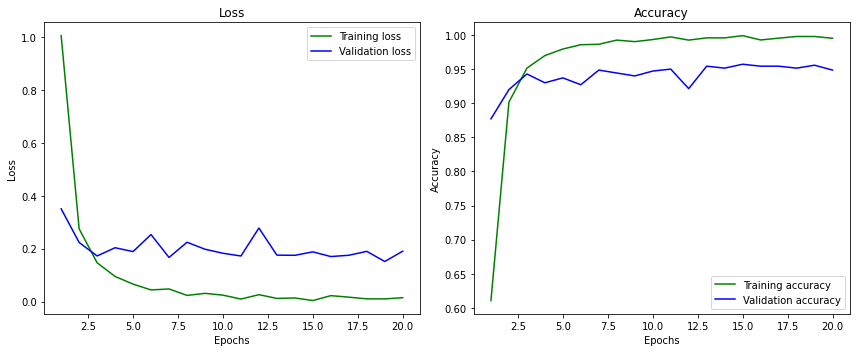

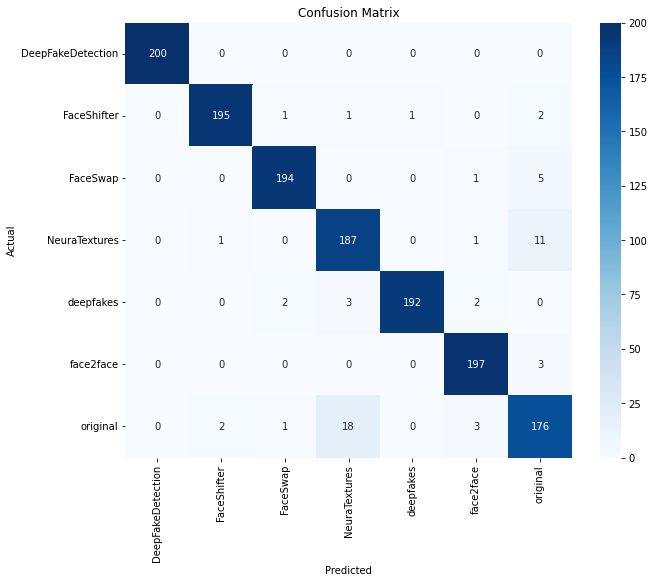

In [45]:
# Graphs
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'g', label='Training loss')
plt.plot(epochs, val_losses, 'b', label='Validation loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'g', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'b', label='Validation accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluation
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=list(train_dataset.class_to_idx.keys()), yticklabels=list(train_dataset.class_to_idx.keys()), cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [48]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

# Verifique se precisa das probabilidades para o AUC
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# F1-score (macro)
f1 = f1_score(all_labels, all_preds, average='macro')

# Acurácia geral
acc = np.mean(np.array(all_preds) == np.array(all_labels))

# Relatório por classe
report = classification_report(all_labels, all_preds, target_names=list(train_dataset.class_to_idx.keys()), zero_division=0)
print("\nClassification Report:\n", report)

# Métricas globais
print(f"\nFinal Evaluation:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  F1-score:  {f1:.4f}")



Classification Report:
                    precision    recall  f1-score   support

DeepFakeDetection       1.00      1.00      1.00       600
      FaceShifter       0.98      0.97      0.98       600
         FaceSwap       0.98      0.97      0.97       600
    NeuraTextures       0.89      0.94      0.91       600
        deepfakes       0.99      0.96      0.98       597
        face2face       0.97      0.98      0.98       600
         original       0.89      0.88      0.89       600

         accuracy                           0.96      4197
        macro avg       0.96      0.96      0.96      4197
     weighted avg       0.96      0.96      0.96      4197


Final Evaluation:
  Accuracy:  0.9585
  F1-score:  0.9587


### Save model

In [46]:
def save_model_to_h5(model, filename):
    model.eval()
    dummy_input = torch.randn(1, sequence_length, 3, 224, 224).to(device)
    traced_model = torch.jit.trace(model, dummy_input)
    traced_model.save('temp_model.pt')
    with open('temp_model.pt', 'rb') as f:
        buffer = f.read()
    with h5py.File(filename, 'w') as h5f:
        h5f.create_dataset('model', data=np.void(buffer))
    os.remove('temp_model.pt')

save_model_to_h5(model, 'best_model.h5')

### XAI

In [ ]:
!pip install opencv-python